# DBSCAN — Customer Personality Analysis

The Customer Personality Analysis dataset describes 2240
grocery customers along demographic and spending dimensions.
Companies use it to discover *segments* of customers without
labels — a textbook unsupervised setting.

DBSCAN groups points by **density** rather than distance to
a centroid: it finds arbitrarily-shaped clusters and labels
sparse points as **noise** (`-1`).

**Core point:** $\;|N_\epsilon(p)| \ge \mathrm{minPts}$, where
$N_\epsilon(p) = \{q : \lVert p - q \rVert \le \epsilon\}$.

**Cluster:** maximal set of mutually density-reachable
points.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rice_ml.processing.datasets import find_data_file

np.random.seed(0)
plt.rcParams["figure.figsize"] = (7, 4.5)

In [2]:
from rice_ml.unsupervised_learning.dbscan import DBSCAN
from sklearn.decomposition import PCA
from rice_ml.processing.pre_processing import StandardScaler

df = pd.read_csv(find_data_file("marketing_campaign.csv"), sep="\t")
print("shape:", df.shape)
df.head(3)

shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0


## Build a small numeric feature set

In [3]:
df = df.dropna(subset=["Income"]).copy()
df["Age"] = 2014 - df["Year_Birth"]
df["TotalSpend"] = (
    df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"]
    + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]
)
df["TotalPurchases"] = (
    df["NumDealsPurchases"] + df["NumWebPurchases"]
    + df["NumCatalogPurchases"] + df["NumStorePurchases"]
)
features = [
    "Age", "Income", "Recency", "TotalSpend", "TotalPurchases",
    "NumWebVisitsMonth", "Kidhome", "Teenhome",
]
X = df[features].to_numpy(dtype=float)

# Strip extreme outliers (the dataset has a few obviously bogus rows
# such as a 130-year-old customer with $666k income).
mask = (df["Age"] < 100) & (df["Income"] < 200000)
X = X[mask.values]
print(f"after outlier filter: {X.shape}")
X_s = StandardScaler().fit_transform(X)

after outlier filter: (2212, 8)


## Project to 2-D for visualization

DBSCAN is run on the full standardized feature set; PCA is
used only to draw the result.

clusters detected = 10,  noise points = 1086


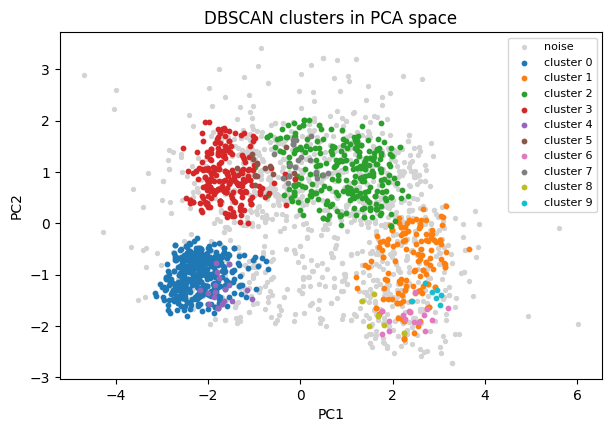

In [4]:
db = DBSCAN(eps=0.9, min_samples=12).fit(X_s)
n_clusters = len(set(db.labels_) - {-1})
n_noise = int((db.labels_ == -1).sum())
print(f"clusters detected = {n_clusters},  noise points = {n_noise}")

pca = PCA(n_components=2).fit(X_s)
Z = pca.transform(X_s)

fig, ax = plt.subplots()
ax.scatter(Z[db.labels_ == -1, 0], Z[db.labels_ == -1, 1],
           c="lightgrey", s=8, label="noise")
for c in sorted(set(db.labels_) - {-1}):
    ax.scatter(Z[db.labels_ == c, 0], Z[db.labels_ == c, 1],
               s=10, label=f"cluster {c}")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("DBSCAN clusters in PCA space")
ax.legend(loc="upper right", fontsize=8)
plt.show()

## Inspect the largest cluster

In [5]:
df_used = df.loc[mask.values].copy()
df_used["cluster"] = db.labels_

cluster_summary = (
    df_used.groupby("cluster")[features]
    .mean()
    .round(1)
    .sort_index()
)
cluster_summary

,Age,Income,Recency,TotalSpend,TotalPurchases,NumWebVisitsMonth,Kidhome,Teenhome
cluster,,,,,,,,
-1,46.9,58499.8,46.3,791.5,17.2,4.9,0.3,0.5
0,35.5,29295.4,48.8,83.2,7.5,7.1,1.0,0.0
1,50.7,76801.1,70.0,1354.0,19.7,1.8,0.0,0.0
2,49.7,58089.8,48.5,671.8,20.3,5.4,0.0,1.0
3,47.1,39222.5,51.3,100.7,8.8,6.5,1.0,1.0
4,29.2,24916.7,14.3,85.3,6.1,6.9,0.0,0.0
5,49.1,38575.8,60.8,112.4,7.8,6.1,0.0,1.0
6,33.7,79337.7,14.0,1798.6,18.6,2.6,0.0,0.0
7,52.8,48154.1,88.1,255.4,11.7,4.8,0.0,1.0


## Takeaways

- DBSCAN identifies a dense "core" group of typical
  customers and a smaller cluster of high-spending,
  high-income outliers; everything else is noise.
- Unlike k-means, we do not need to commit to a fixed number
  of clusters — `eps` and `min_samples` decide that
  implicitly.
- The result is sensitive to feature scaling and to outlier
  filtering; the dataset has a handful of patently
  unrealistic records that distort distances if left in.